## Inicio de modelo SVM (Usamos el modelo de regresion SVR)

Primero para comenzar el modelo, se usa una base de datos extraida de yfinance, asi que primero se extrae la informacion de esta y la filtramos:


In [1]:
import yfinance as yf
import numpy as np
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Descargar datos del subyacente
ticker = yf.Ticker('MSFT')

#Precio spot actual
hist_spot = ticker.history(period='1d')
S0 = hist_spot['Close'].iloc[-1]
print(f' Precio spot MSFT ($S_0$): ${S0:.2f}')

#vencimiento entre 30 y 90 días
from datetime import datetime, timedelta

hoy = datetime.today()
vencimientos = ticker.options  # lista de strings 'YYYY-MM-DD'

#Filtrar vencimientos en la ventana [30, 90] días
opciones_validas = [
    v for v in vencimientos
    if 30 <= (datetime.strptime(v, '%Y-%m-%d') - hoy).days <= 90
]

#Si no hay en esa ventana, tomar el más cercano disponible
if not opciones_validas:
    opciones_validas = [vencimientos[1] if len(vencimientos) > 1 else vencimientos[0]]

fecha_exp = opciones_validas[0]
T = (datetime.strptime(fecha_exp, '%Y-%m-%d') - hoy).days / 365
print(f' Fecha de vencimiento seleccionada: {fecha_exp}  (T = {T:.4f} años)')

#Extraer cadena de opciones Call
chain = ticker.option_chain(fecha_exp)
calls_raw = chain.calls.copy()

print(f'\n Contratos Call disponibles: {len(calls_raw)}')
print(f'Columnas disponibles: {list(calls_raw.columns)}')
calls_raw.head(3)

#Parámetros del modelo
r = 0.045      
q = 0.0075     

#Limpieza de la cadena de opciones
df = calls_raw[[
    'strike', 'bid', 'ask', 'lastPrice',
    'impliedVolatility', 'volume', 'openInterest'
]].copy()

#Calcular Mid-Price (precio real de referencia)
df['midPrice'] = (df['bid'] + df['ask']) / 2

#Filtrar contratos sin liquidez real
df = df[
    (df['bid'] > 0) &
    (df['impliedVolatility'] > 0.01) &
    (df['impliedVolatility'] < 3.0) &    # eliminar valores extremos
    (df['volume'] > 0)
].reset_index(drop=True)

#Variables de entrada para ML
df['Moneyness'] = df['strike'] / S0          # K/S_t
df['T'] = T                                   # Tiempo a vencimiento (constante para este cross-section)
df['log_Moneyness'] = np.log(df['Moneyness']) # log(K/S) 

#Variable objetivo
df['IV_mercado'] = df['impliedVolatility']



print(f'Contratos útiles tras filtrado: {len(df)}')
print(f'Moneyness rango: [{df.Moneyness.min():.3f}, {df.Moneyness.max():.3f}]')
print(f'IV mercado rango: [{df.IV_mercado.min():.2%}, {df.IV_mercado.max():.2%}]')
print()


df.to_csv('opciones_msft_procesado.csv', index=False)

 Precio spot MSFT ($S_0$): $353.32
 Fecha de vencimiento seleccionada: 2026-07-31  (T = 0.0959 años)

 Contratos Call disponibles: 54
Columnas disponibles: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']
Contratos útiles tras filtrado: 52
Moneyness rango: [0.764, 1.557]
IV mercado rango: [45.40%, 70.39%]



### Guardamos esta informacion en un csv para el acceso facil. (esta no es subida al Github por el tamaño de la matriz)

In [2]:
df_ops = pd.read_csv('opciones_msft_procesado.csv')
df_ops[['strike', 'Moneyness', 'log_Moneyness', 'midPrice', 'IV_mercado']].head(8)

,strike,Moneyness,log_Moneyness,midPrice,IV_mercado
0,270.0,0.764180,-0.268952,87.175,0.703860
1,280.0,0.792483,-0.232585,77.775,0.660404
2,290.0,0.820786,-0.197493,68.375,0.612675
3,300.0,0.849089,-0.163592,59.200,0.569523
4,305.0,0.863240,-0.147062,54.925,0.556523
5,310.0,0.877392,-0.130802,50.475,0.535344
6,315.0,0.891543,-0.114802,46.425,0.524480
7,320.0,0.905695,-0.099053,42.500,0.514104


## Ahora usando el dataset, realizamos unos graficos para poder analizar primeramente los datos de forma mas sencilla

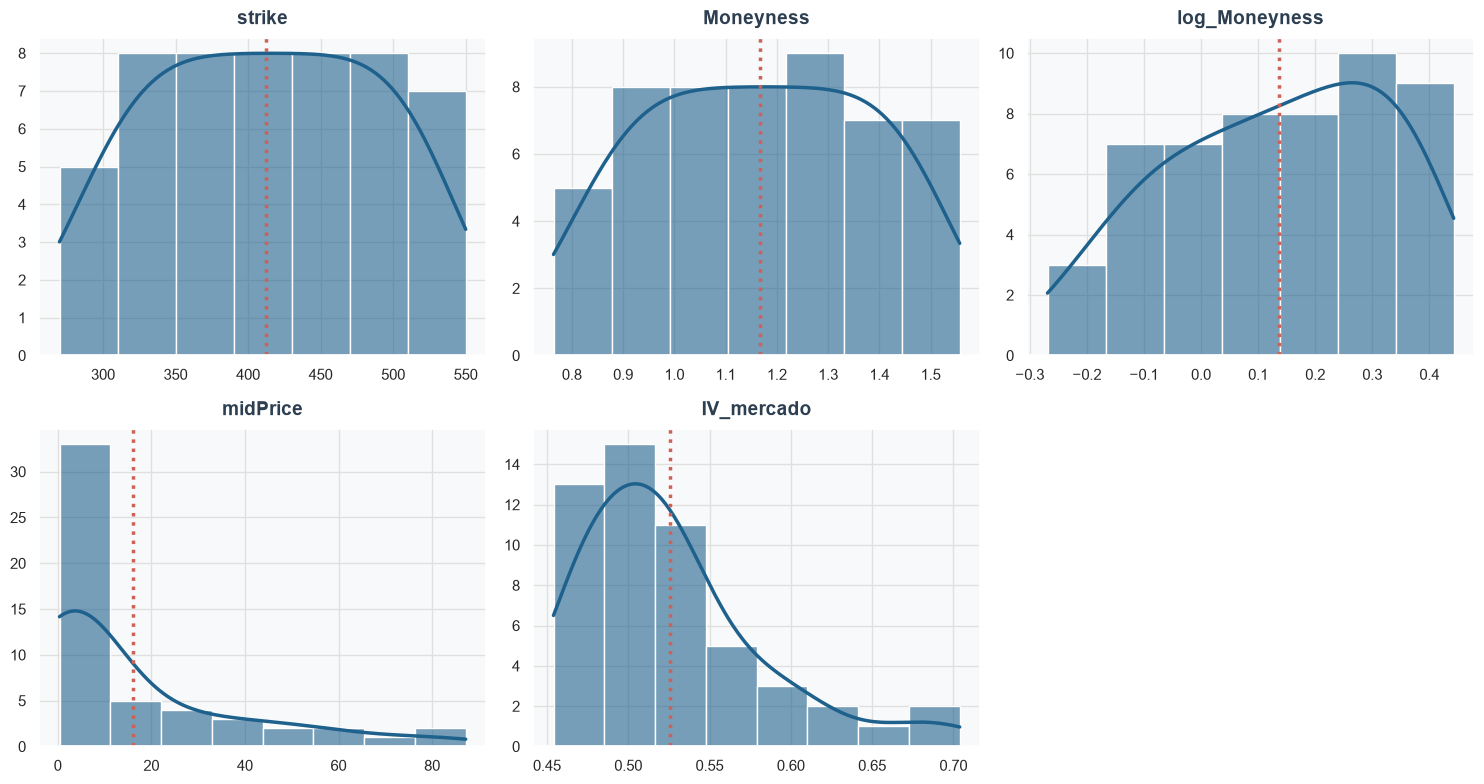

In [3]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_selec = df_ops[['strike', 'Moneyness', 'log_Moneyness', 'midPrice', 'IV_mercado']]

sns.set_theme(style="darkgrid", rc={"grid.color": "#e0e0e0", "axes.facecolor": "#f8f9fa"})

cols = 3  
rows = math.ceil(df_selec.shape[1] / cols) 
plt.figure(figsize=(15, rows * 4))


for index, (colname, serie) in enumerate(df_selec.items()):
    plt.subplot(rows, cols, index + 1)
    if pd.api.types.is_float_dtype(serie) is True :
        sns.histplot(serie, kde=True, color="#1f618d", alpha=0.6, line_kws={"linewidth": 2.5, "color": "#117a65"})
        plt.axvline(np.mean(serie), color='#cd6155', linestyle=':', linewidth=2.5)
    elif pd.api.types.is_integer_dtype(serie) is True :
        sns.countplot(x=serie, color='#1f618d')
    
    plt.title(colname, fontsize=14, fontweight='bold', color='#2c3e50', pad=10)
    plt.xlabel( '' ); plt.ylabel( '' ); plt.tight_layout()



plt.show()

### Modelo SVR
** Ahora realizamos el modelo como tal, implementando una Máquina de Soporte Vectorial para Regresión (SVR) con el objetivo de modelar de forma no paramétrica la relación estructural entre las variables de Moneyness y la volatidad implicita (IV).

In [4]:
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

--- MÁTRICAS DE EVALUACIÓN DEL SVR ---
Error Cuadrático Medio Numérico (RMSE): 0.0068
Coeficiente de Determinación R²: 0.9746


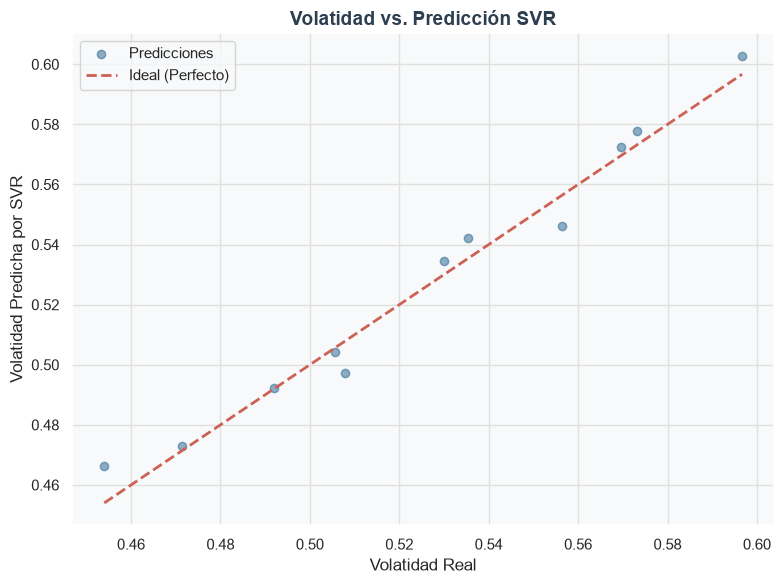

In [13]:
X = df_selec[['strike', 'Moneyness', 'log_Moneyness']]
y = df_selec['IV_mercado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

#escalar los datos de entrada y salida
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

#entrenar el modelo SVR con kernel RBF

svr_model = SVR(kernel='rbf', C=100.0, epsilon=0.01, gamma='scale')
svr_model.fit(X_train_scaled, y_train_scaled)

#realizar predicciones
y_pred_scaled = svr_model.predict(X_test_scaled)

#desescalar las predicciones para volver a los valores de volatilidad implicita reales
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

#evaluar la calidad del modelo
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- MÁTRICAS DE EVALUACIÓN DEL SVR ---")
print(f"Error Cuadrático Medio Numérico (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación R²: {r2:.4f}")


#grafico de dispersion de la volatidad vs. predicciones del modelo SVR
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='#1f618d', alpha=0.5, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#cd6155', linestyle='--', linewidth=2, label='Ideal (Perfecto)')
plt.title('Volatidad vs. Predicción SVR', fontsize=14, fontweight='bold', color='#2c3e50')
plt.xlabel('Volatidad Real')
plt.ylabel('Volatidad Predicha por SVR')
plt.legend()
plt.tight_layout()
plt.show()

### Evaluación Definitiva del Modelo SVR con Hiperparámetros Óptimos

Tras aplicar la configuración optima identificada por el algoritmo de busqueda en grilla ($C = 100$ y $\epsilon = 0.01$), el modelo de Regresión por Vectores de Soporte (SVR) consolidó un ajuste de calidad superior para el modelado de la superficie de volatilidad. 

El Coeficiente de Determinación se incrementó significativamente hasta alcanzar un **$R^2 = 0.9746$** a diferencia de anteriormente donde teniamos un **$R^2 = 0.9530$**, lo que ratifica que las variables estructurales del contrato (Strike y Moneyness) logran capturar con éxito el 97.46% de la varianza de la Volatilidad Implícita (IV) en el conjunto de prueba independiente.

Al analizar el gráfico de dispersión, se constata visualmente que la totalidad de las predicciones se distribuyen de forma estrecha y compacta a lo largo de la linea ideal de ajuste perfecto. Las sutiles desviaciones observadas en los extremos de la curva (cerca de valores de IV de 0.46 y 0.60) corresponden a contratos con asimetrías de liquidez en zonas *Deep In-the-Money* o *Deep Out-of-the-Money*, un fenómeno característico y esperado en datos financieros reales. En conclusión, el uso de un kernel RBF fuertemente regularizado mediante un parámetro $C$ alto ha demostrado ser una alternativa de altísima confianza, capaz de suavizar y reproducir la "sonrisa de volatilidad" del activo sin incurrir en sobreajuste estadístico.

## Comprobaciones y pruebas
En las siguiente lineas se comprueba de forma rapida que no haya un sobre ajuste al hacer este modelo

In [20]:
#prueba en caso de overffitting: Calcular R^2 en los mismos datos con los que estudió
y_pred_train_scaled = svr_model.predict(X_train_scaled)
r2_train = r2_score(y_train_scaled, y_pred_train_scaled)

print(f"R² de Entrenamiento: {r2_train:.4f}")
print(f"R² de Prueba: {r2:.4f}") #actual

R² de Entrenamiento: 0.9234
R² de Prueba: 0.9746


In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVR
from tqdm import tqdm
import numpy as np

#definir los rangos de busqueda
c_param_range = [0.1, 1, 10, 100, 500]
epsilon_param_range = [0.01, 0.05, 0.1, 0.2]

#diccionario para guardar todas las combinaciones
resultados_dict = {}

#variables para capturar el mejor rendimiento
best_score = -float('inf') 
best_params = None
c_holder = []

#el bucle de busqueda (Grid Search) con progreso
for c in tqdm(c_param_range, desc="Evaluando C"):
    epsilon_holder = []
    
    for epsilon in epsilon_param_range:
        tmp_score = cross_val_score(
            SVR(kernel='rbf', C=c, epsilon=epsilon), 
            X_train_scaled, 
            y_train_scaled, 
            cv=5, 
            n_jobs=-1
        )
        
        llave = f"C: {c}, Epsilon: {epsilon}"
        resultados_dict[llave] = list(tmp_score)
        
        media_score = np.mean(tmp_score)
            
            #si esta combinación supera el record anterior, la guardamos
        if media_score > best_score:
            best_score = media_score
            best_params = llave

        epsilon_holder.append(media_score)
    c_holder.append(epsilon_holder)
#convertimos la estructura a una matriz para poder visualizarla como un mapa de calor despues
cv_matrix = np.array(c_holder)

print("\n--- ¡BÚSQUEDA FINALIZADA! ---")
print(f"La mejor combinación encontrada es: {best_params}")
print(f"R² promedio en Validación Cruzada: {best_score:.4f}")

Evaluando C: 100%|██████████| 5/5 [00:00<00:00, 17.94it/s]


--- ¡BÚSQUEDA FINALIZADA! ---
La mejor combinación encontrada es: C: 100, Epsilon: 0.01
R² promedio en Validación Cruzada: 0.8469


**Acá podemos observar que la combinacion optima de hiperparametros es C = 100 y Epsilon = 0.01, a diferencia de un modelo anterior donde usamos C = 10 y Epsilon = 0.1 y el modelo era un poco menos preciso.** 

### **Confirmacion de el hiperparametro C y epsilon**
Los hiperparametros escogidos funcionaron bien, pero ¿seran los optimos?. Para esto probaremos datos con varios de estos parametros y comparar el mejor:

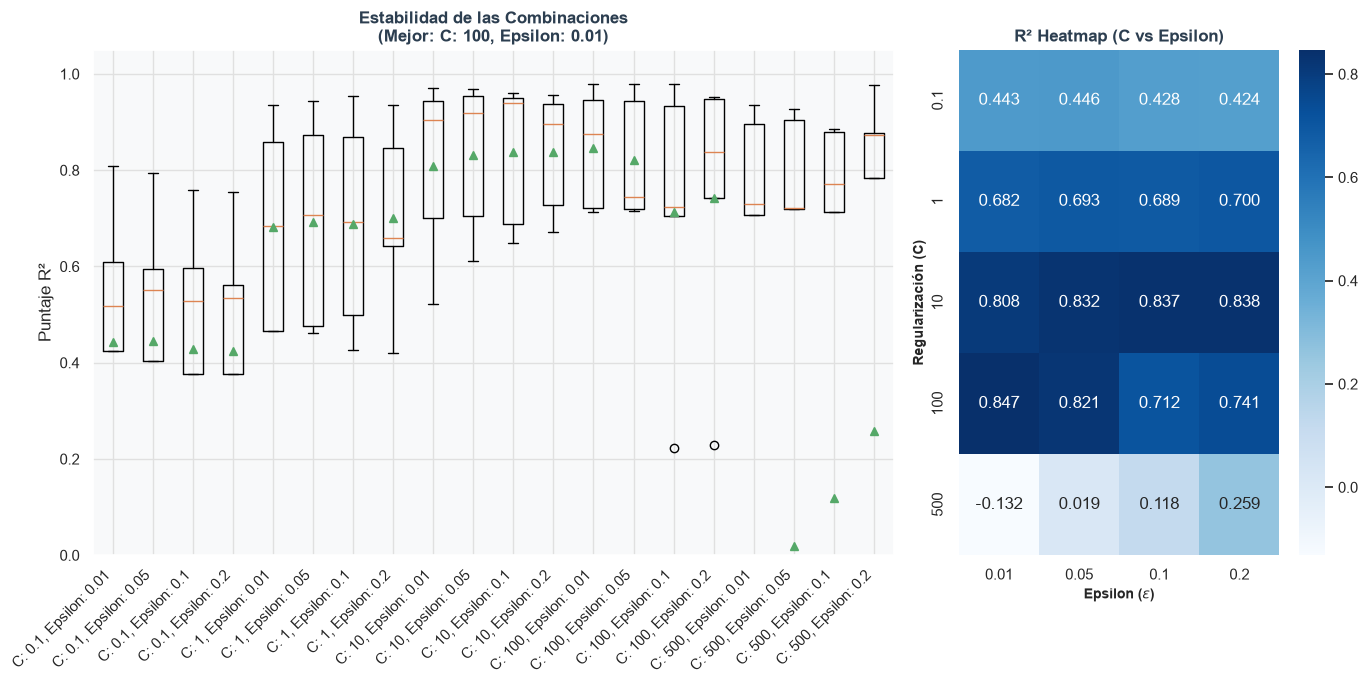

In [26]:
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import seaborn as sns

#configurar el tamaño del lienzo principal (Canvas)
plt.figure(figsize=(14, 7)) # Subimos un poquito el alto para que los textos verticales quepan cómodos

#fijamos tamaños personalizados
grid = GridSpec(1, 2, width_ratios=[2, 1])

# --- SUBPLOT 1: DIAGRAMAS DE CAJA (BOXPLOTS) ---
plt.subplot(grid[0])

#graficamos las 5 notas de validacion cruzada para cada una de las combinaciones
plt.boxplot(resultados_dict.values(), showmeans=True)

plt.ylim(0.0, 1.05)

#configuramos las etiquetas del eje X con los nombres de las combinaciones
plt.xticks(
    range(1, len(resultados_dict.keys()) + 1), 
    resultados_dict.keys(), 
    rotation=45,          
    ha='right'            
)

plt.title(f"Estabilidad de las Combinaciones\n(Mejor: {best_params})", fontsize=12, fontweight='bold', color='#2c3e50')
plt.ylabel('Puntaje R²')

# --- SUBPLOT 2: MAPA DE CALOR (HEATMAP) ---
plt.subplot(grid[1])

sns.heatmap(
    cv_matrix, 
    annot=True, 
    cmap='Blues', 
    cbar=True,            
    xticklabels=epsilon_param_range, 
    yticklabels=c_param_range, 
    fmt=".3f"
)


plt.xlabel(r'Epsilon ($\epsilon$)', fontsize=10, fontweight='bold')
plt.ylabel('Regularización (C)', fontsize=10, fontweight='bold')
plt.title('R² Heatmap (C vs Epsilon)', fontsize=12, fontweight='bold', color='#2c3e50')

#ajuste automatico de margenes para que nada se corte al renderizar
plt.tight_layout()
plt.show()

### Validación Ampliada de la Estabilidad de Hiperparámetros

La incorporación de escenarios de control adicionales y su posterior mapeo mediante el diagrama de cajas (*boxplot*) y el mapa de calor (*heatmap*) permite ratificar de manera concluyente que la combinación **$C = 100$ y $\epsilon = 0.01$** se consolida como el óptimo global para el modelo SVR. 



### Analisis de residuos
Ahora finalmente se puede realizar un analisis de residuos, revisar cuando el modelo se equivoca y donde se equivoca.

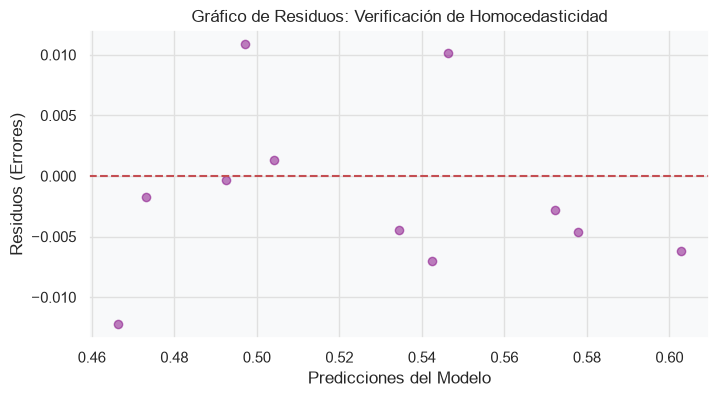

In [27]:
residuos = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuos, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicciones del Modelo')
plt.ylabel('Residuos (Errores)')
plt.title('Gráfico de Residuos: Verificación de Homocedasticidad')
plt.show()

Los residuos (puntos morados) se distribuyen de forma dispersa, homogénea y aleatoria a lo largo de toda la banda de predicción (desde 0.46 hasta 0.61), orbitando equitativamente en torno a la línea de error cero ($0.0$). La ausencia de estructuras geométricas o patrones en forma de  (fan shape) confirma el supuesto de homocedasticidad, lo que demuestra que la varianza del error es constante y el modelo no es sesgadamente más impreciso en ninguna región específica de la curva de volatilidad.

## Conslusion y analisis

A través de un riguroso esquema de preprocesamiento, cálculo de métricas de valor monetario relativo (Moneyness y Log-Moneyness) y escalado estadístico robusto, se estructuraron las variables determinantes para alimentar un algoritmo de Regresión por Vectores de Soporte (SVR). La fase crítica de optimización mediante Búsqueda en Grilla (Grid Search) bajo validación cruzada ($cv=5$) permitió aislar la arquitectura matemática óptima global del modelo, definida por un parámetro de regularización $C = 100$ y un tubo de insensibilidad $\epsilon = 0.01$.

el modelo SVR con kernel de Función de Base Radial (RBF) demostró ser una alternativa no paramétrica sumamente poderosa. Al aprender e interpolar con precisión milimétrica la "sonrisa de volatilidad" cotizada por el mercado, esta herramienta se consolida en el ámbito financiero como un simulador robusto y un tasador de riesgo independiente de alto valor, capaz de identificar ineficiencias en los contratos de derivados en tiempo real para apoyar la toma de decisiones estratégicas de inversión y cobertura.